# Импорт библиотек

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Подготовка СIFAR-10

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 60s 0us/step


/Users/lunis/PycharmProjects/machine_learning/.venv/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [5]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [6]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [7]:
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


Разделение train/val

In [8]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train_small = x_train[:-5000]
y_train_small = y_train[:-5000]

Визуализация CIFAR-10

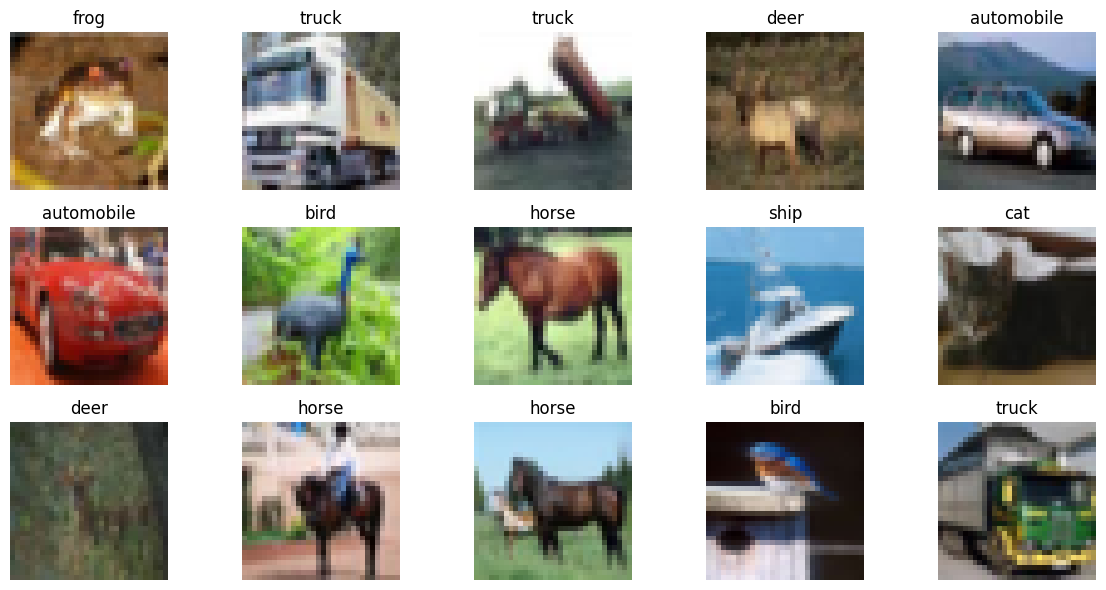

In [9]:
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train_small[i])
    plt.title(class_names[y_train_small[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Обучение

In [10]:
def make_model_1():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

In [11]:
def make_model_2():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])
    return model

In [12]:
def make_model_3():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(10, activation="softmax")
    ])
    return model

In [13]:
def train_model(model, name, epochs=15, batch_size=64):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_small, y_train_small,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=[early_stop]
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return {
        "name": name,
        "model": model,
        "history": history.history,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "best_val_acc": max(history.history["val_accuracy"])
    }

In [14]:
models = [
    ("Basic CNN", make_model_1()),
    ("CNN + BN + Dropout", make_model_2()),
    ("CNN + GAP", make_model_3())
]

In [15]:
results = []
for name, model in models:
    print(f"\n===== {name} =====")
    model.summary()
    result = train_model(model, name)
    results.append(result)


===== Basic CNN =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,194 (1.10 MB)

 Trainable params: 288,746 (1.10 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 155ms/step - accuracy: 0.5041 - loss: 1.3668 - val_accuracy: 0.5342 - val_loss: 1.3369
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.6461 - loss: 1.0091 - val_accuracy: 0.6704 - val_loss: 0.9595
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.6922 - loss: 0.8780 - val_accuracy: 0.7124 - val_loss: 0.8342
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 140ms/step - accuracy: 0.7292 - loss: 0.7810 - val_accuracy: 0.7532 - val_loss: 0.7094
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7533 - loss: 0.7112 - val_accuracy: 0.7730 - val_loss: 0.6668
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.7753 - loss: 0.6547 - val_accuracy: 0.8034 - val_loss: 0.5675
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7841 - loss: 0.6206 - val_accuracy: 0.7382 - val_loss: 0.7681
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7990 - loss: 

In [16]:
results_df = pd.DataFrame([
    {
        "model": r["name"],
        "test_loss": r["test_loss"],
        "test_accuracy": r["test_acc"],
        "best_val_accuracy": r["best_val_acc"]
    }
    for r in results
]).sort_values("test_accuracy", ascending=False)

In [17]:
print("\nРезультаты:")
print(results_df)


Результаты:
                model  test_loss  test_accuracy  best_val_accuracy
2           CNN + GAP   0.523544         0.8231             0.8338
1  CNN + BN + Dropout   0.597943         0.7955             0.8132
0           Basic CNN   0.878211         0.7108             0.7246


**Вывод**:
- Лучшая модель — CNN + GAP
- Basic CNN заметно уступает двум другим моделям
- CNN + BN + Dropout улучшила результат по сравнению с базовой моделью, но уступила CNN + GAP

Визуализация результатов

In [18]:
def plot_training_curves(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["accuracy"], label="train_accuracy")
    plt.plot(history["val_accuracy"], label="val_accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

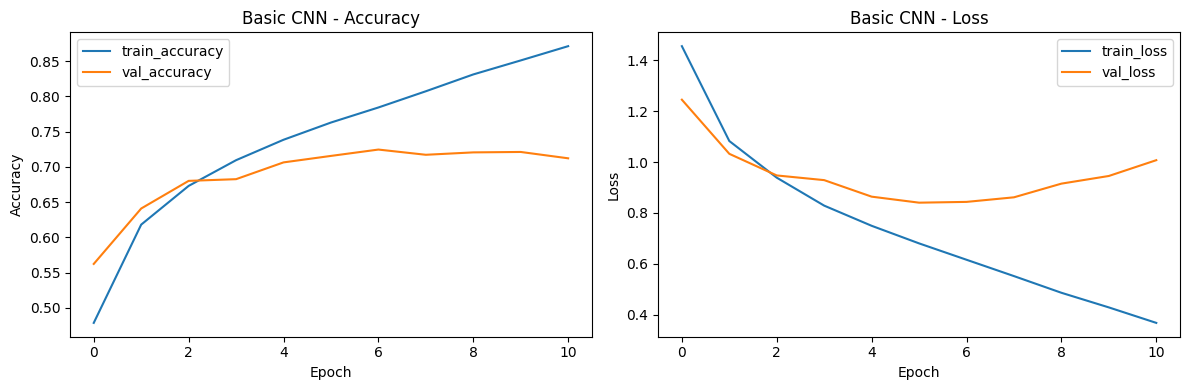

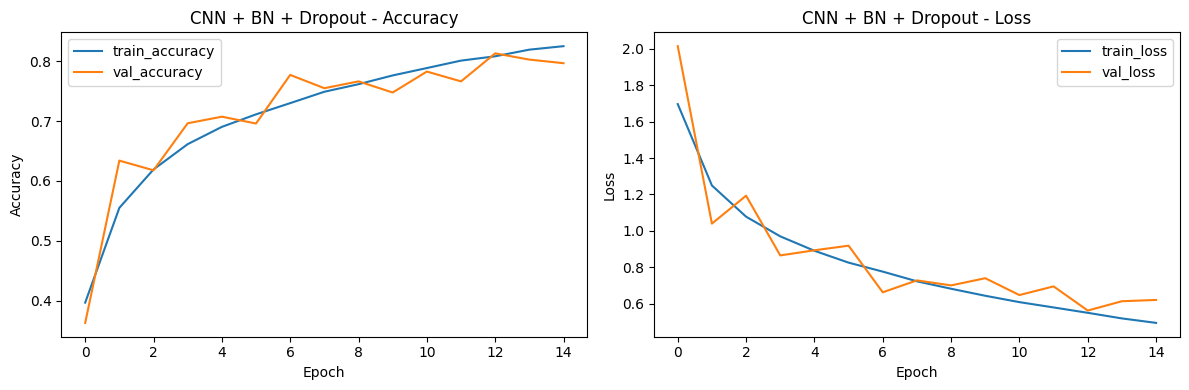

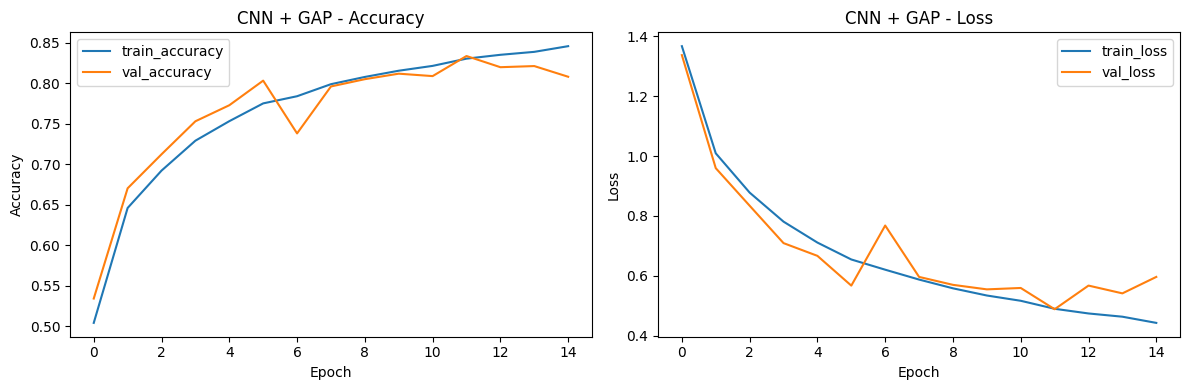

In [19]:
for r in results:
    plot_training_curves(r["history"], r["name"])

**Вывод**:
- У Basic CNN типичный признак переобучения: модель всё лучше запоминает обучающую выборку, но качество на валидации перестаёт расти
- У CNN + BN + Dropout видно, что Batch Normalization и Dropout действительно помогли улучшить обобщающую способность модели по сравнению с Basic CNN
- CNN + GAP показывает лучшее соотношение качества и устойчивости обучения

In [20]:
best_result = max(results, key=lambda x: x["test_acc"])
best_model = best_result["model"]

In [21]:
print(f"\nЛучшая модель: {best_result['name']}")
print(f"Test accuracy: {best_result['test_acc']:.4f}")


Лучшая модель: CNN + GAP
Test accuracy: 0.8231


Матрица ошибок

In [22]:
y_pred_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

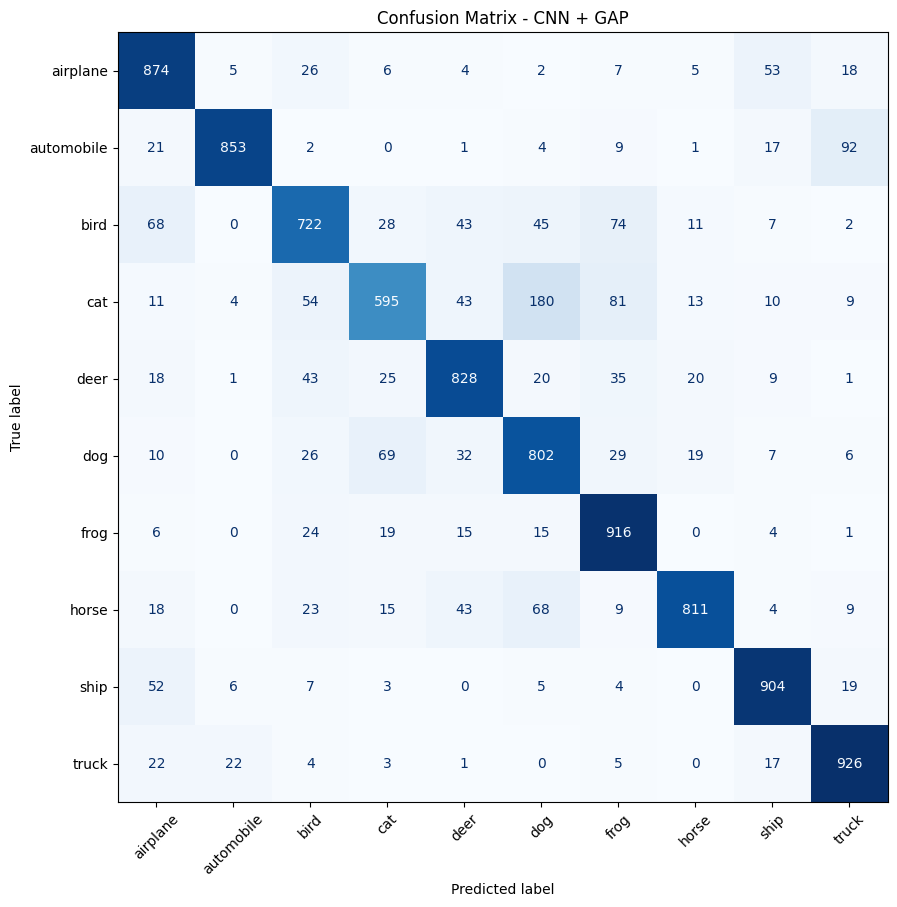

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_result['name']}")
plt.show()

Вывод:
- Самая заметная ошибка — это путаница между cat и dog
- Также модель путает automobile и truck, airplane и ship, часть животных между собой: cat, dog, deer, horse, bird, frog

In [25]:
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification report:
              precision    recall  f1-score   support

    airplane       0.79      0.87      0.83      1000
  automobile       0.96      0.85      0.90      1000
        bird       0.78      0.72      0.75      1000
         cat       0.78      0.59      0.67      1000
        deer       0.82      0.83      0.82      1000
         dog       0.70      0.80      0.75      1000
        frog       0.78      0.92      0.84      1000
       horse       0.92      0.81      0.86      1000
        ship       0.88      0.90      0.89      1000
       truck       0.86      0.93      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



**Вывод**:
- Лучше всего модель распознаёт truck, frog, ship, automobile, horse
- Хуже всего модель распознаёт cat, dog, bird

Предсказания

In [27]:
def show_predictions(images, y_true, y_pred, class_names, correct=True, n=12):
    indices = np.where(y_true == y_pred)[0] if correct else np.where(y_true != y_pred)[0]
    indices = indices[:n]

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[idx])
        plt.title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Примеры правильных предсказаний:


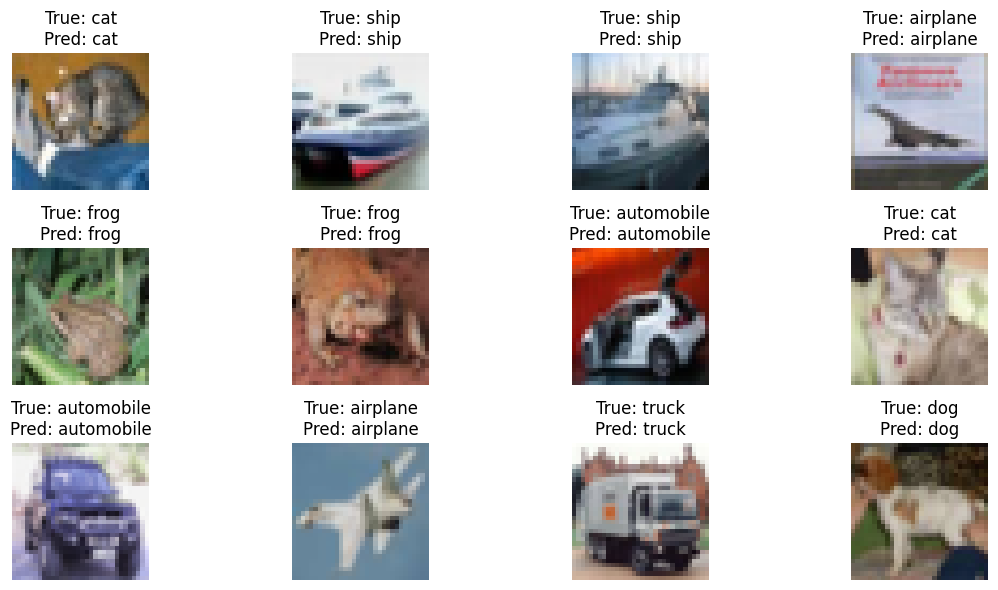


Примеры ошибочных предсказаний:


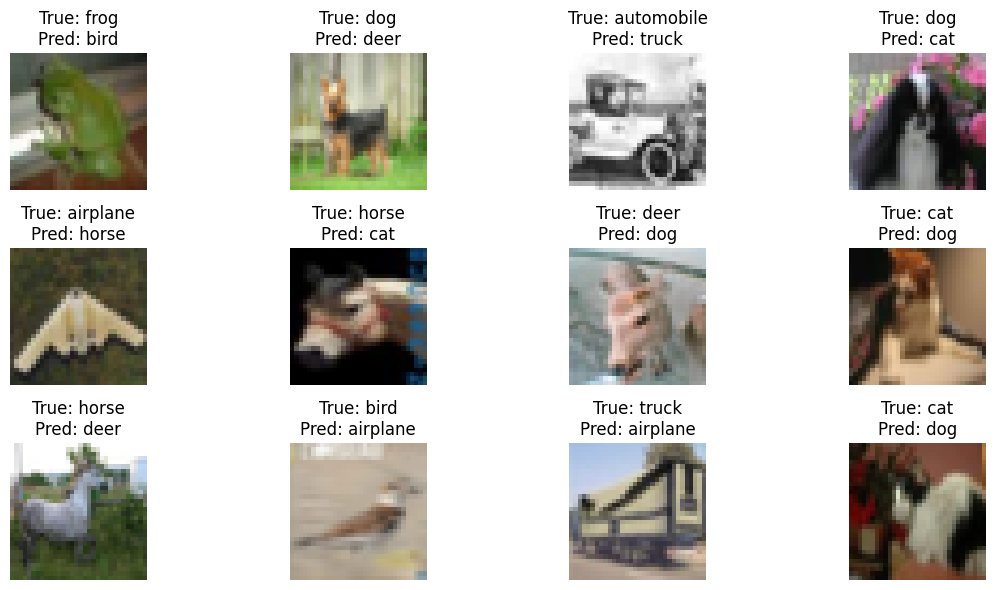

In [28]:
print("\nПримеры правильных предсказаний:")
show_predictions(x_test, y_test, y_pred, class_names, correct=True, n=12)

print("\nПримеры ошибочных предсказаний:")
show_predictions(x_test, y_test, y_pred, class_names, correct=False, n=12)